In [8]:
!pip install transformers torch lime shap langdetect datasets -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 20.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [9]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from transformers import pipeline
from lime.lime_text import LimeTextExplainer
import shap
from langdetect import detect, LangDetectException
import warnings
warnings.filterwarnings("ignore")

print("All imports successful.")

All imports successful.


In [10]:
classifier = pipeline(
    "text-classification",
    model="SamLowe/roberta-base-go_emotions",
    top_k=None,
    device=0 if torch.cuda.is_available() else -1  # use GPU if available
)

# Sanity check
sample = classifier("I can't believe they pulled it off!")[0]
top = max(sample, key=lambda x: x['score'])
print(f"Model loaded. Sample prediction: {top['label']} ({top['score']:.2%})")

config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: SamLowe/roberta-base-go_emotions
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/798k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.11M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

Model loaded. Sample prediction: surprise (66.24%)



Text: "Today was the worst day of my entire life."
Prediction: SADNESS (71.4%)



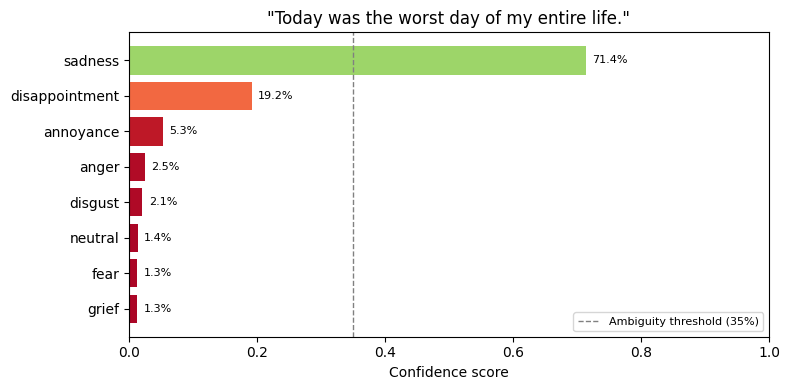

('sadness', 0.7141915559768677)

In [11]:
AMBIGUITY_THRESHOLD = 0.35
TOP_N_DISPLAY = 8  # show top 8 out of 28 emotions

def detect_language(text):
    try:
        lang = detect(text)
        if lang != 'en':
            print(f"[WARNING] Detected language: '{lang}'. This model is trained on English."
                  " Results may be unreliable.")
    except LangDetectException:
        print("[WARNING] Could not detect language.")

def predict_emotions(text, show_plot=True):
    detect_language(text)

    results = classifier(text)[0]
    results = sorted(results, key=lambda x: x['score'], reverse=True)
    top_label = results[0]['label']
    top_score = results[0]['score']

    if top_score < AMBIGUITY_THRESHOLD:
        verdict = f"AMBIGUOUS (top score {top_score:.1%} < threshold {AMBIGUITY_THRESHOLD:.0%})"
    else:
        verdict = f"{top_label.upper()} ({top_score:.1%})"

    print(f'\nText: "{text}"')
    print(f"Prediction: {verdict}\n")

    if show_plot:
        top_results = results[:TOP_N_DISPLAY]
        labels = [r['label'] for r in top_results]
        scores = [r['score'] for r in top_results]

        cmap = plt.cm.RdYlGn
        colors = [cmap(s) for s in scores]

        fig, ax = plt.subplots(figsize=(8, 4))
        bars = ax.barh(labels[::-1], scores[::-1], color=colors[::-1])
        ax.axvline(x=AMBIGUITY_THRESHOLD, color='gray', linestyle='--',
                   linewidth=1, label=f'Ambiguity threshold ({AMBIGUITY_THRESHOLD:.0%})')
        ax.set_xlim(0, 1)
        ax.set_xlabel("Confidence score")
        ax.set_title(f'Top {TOP_N_DISPLAY} emotions — "{text[:50]}..."' if len(text)>50 else f'"{text}"')
        for bar, score in zip(bars, scores[::-1]):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                    f"{score:.1%}", va='center', fontsize=8)
        ax.legend(fontsize=8)
        plt.tight_layout()
        plt.show()

    return top_label, top_score

predict_emotions("Today was the worst day of my entire life.")

In [12]:
def get_sorted_labels():
    """Get all 28 labels sorted alphabetically — LIME needs consistent ordering."""
    dummy = classifier("test")[0]
    return sorted([r['label'] for r in dummy])

ALL_LABELS = get_sorted_labels()
explainer_lime = LimeTextExplainer(class_names=ALL_LABELS)

def predict_proba_for_lime(texts):
    all_scores = []
    for text in texts:
        result = classifier(text)[0]
        label_to_score = {r['label']: r['score'] for r in result}
        all_scores.append([label_to_score.get(lbl, 0.0) for lbl in ALL_LABELS])
    return np.array(all_scores)

def explain_lime(text, num_samples=500):
    detect_language(text)
    results = classifier(text)[0]
    label_to_score = {r['label']: r['score'] for r in results}
    top_label = max(results, key=lambda x: x['score'])['label']
    top_idx = ALL_LABELS.index(top_label)

    print(f'\nLIME explanation for: "{text}"')
    print(f"Explaining predicted class: {top_label.upper()}\n")

    exp = explainer_lime.explain_instance(
        text,
        predict_proba_for_lime,
        num_features=10,
        num_samples=num_samples,
        labels=[top_idx]
    )
    exp.show_in_notebook(text=True, labels=[top_idx])

explain_lime("I can't believe they actually fired me after ten years.")


LIME explanation for: "I can't believe they actually fired me after ten years."
Explaining predicted class: SURPRISE



In [13]:
def explain_shap(text):
    detect_language(text)

    results = classifier(text)[0]
    top_label = max(results, key=lambda x: x['score'])['label']

    print(f'\nSHAP explanation for: "{text}"')
    print(f"Target class: {top_label.upper()}\n")

    # SHAP needs a simple string→string function
    def model_fn(texts):
        outputs = []
        for t in texts:
            res = classifier(t)[0]
            label_to_score = {r['label']: r['score'] for r in res}
            outputs.append(label_to_score.get(top_label, 0.0))
        return np.array(outputs)

    masker = shap.maskers.Text(r"\W+")  # mask by whitespace-split words
    shap_explainer = shap.Explainer(model_fn, masker)
    shap_values = shap_explainer([text])

    shap.plots.text(shap_values[0])

explain_shap("I am devastated but also strangely relieved.")


SHAP explanation for: "I am devastated but also strangely relieved."
Target class: SADNESS



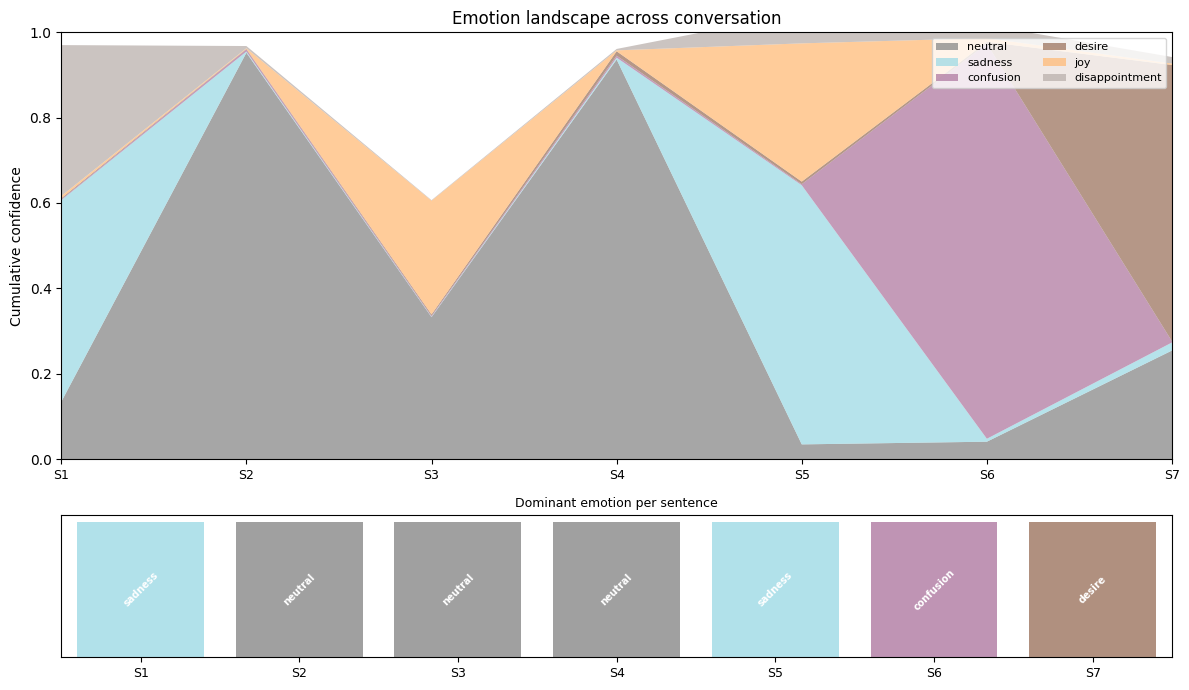


Sentence key:
  S1: I woke up today feeling completely empty.
  S2: Got a message from an old friend out of nowhere.
  S3: We talked for hours, just like the old days.
  S4: She told me she's moving abroad next month.
  S5: I feel happy for her but also lost.
  S6: I don't know what I was expecting, honestly.
  S7: I think I just need some time alone.


In [14]:
EMOTION_COLORS_28 = {
    "admiration": "#4e79a7", "amusement": "#f28e2b", "anger": "#e15759",
    "annoyance": "#76b7b2", "approval": "#59a14f", "caring": "#edc948",
    "confusion": "#b07aa1", "curiosity": "#ff9da7", "desire": "#9c755f",
    "disappointment": "#bab0ac", "disapproval": "#d37295", "disgust": "#8c564b",
    "embarrassment": "#bcbd22", "excitement": "#17becf", "fear": "#e377c2",
    "gratitude": "#2ca02c", "grief": "#1f77b4", "joy": "#ffbb78",
    "love": "#ff7f0e", "nervousness": "#aec7e8", "optimism": "#98df8a",
    "pride": "#c5b0d5", "realization": "#c49c94", "relief": "#f7b6d2",
    "remorse": "#dbdb8d", "sadness": "#9edae5", "surprise": "#ad494a",
    "neutral": "#888888"
}

# Pick emotions that are interesting to track (top emotions that appear)
def plot_emotion_trend_stacked(sentences, top_k_emotions=6):
    all_scores = []
    top_emotions = []

    for s in sentences:
        results = classifier(s)[0]
        label_to_score = {r['label']: r['score'] for r in results}
        all_scores.append(label_to_score)
        top_emotions.append(max(results, key=lambda x: x['score'])['label'])

    # Find which emotions have highest average score across sentences
    avg_scores = {}
    for label in ALL_LABELS:
        avg_scores[label] = np.mean([s.get(label, 0) for s in all_scores])
    top_tracked = sorted(avg_scores, key=avg_scores.get, reverse=True)[:top_k_emotions]

    x = range(len(sentences))
    score_matrix = np.array([[s.get(lbl, 0) for lbl in top_tracked] for s in all_scores])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), gridspec_kw={'height_ratios': [3, 1]})

    # Stacked area
    colors = [EMOTION_COLORS_28.get(lbl, "#aaa") for lbl in top_tracked]
    ax1.stackplot(x, score_matrix.T, labels=top_tracked, colors=colors, alpha=0.75)
    ax1.set_xlim(0, len(sentences)-1)
    ax1.set_ylim(0, 1)
    ax1.set_ylabel("Cumulative confidence")
    ax1.set_title("Emotion landscape across conversation")
    ax1.legend(loc='upper right', fontsize=8, ncol=2)
    ax1.set_xticks(list(x))
    ax1.set_xticklabels([f"S{i+1}" for i in x], fontsize=9)

    # Dominant emotion strip
    for i, (emotion, score) in enumerate(zip(top_emotions, [max(s.values()) for s in all_scores])):
        color = EMOTION_COLORS_28.get(emotion, "#aaa")
        ax2.bar(i, 1, color=color, alpha=0.8, width=0.8)
        ax2.text(i, 0.5, emotion, ha='center', va='center', fontsize=7,
                 rotation=45, color='white', fontweight='bold')
    ax2.set_xlim(-0.5, len(sentences)-0.5)
    ax2.set_yticks([])
    ax2.set_xticks(list(x))
    ax2.set_xticklabels([f"S{i+1}" for i in x], fontsize=9)
    ax2.set_title("Dominant emotion per sentence", fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\nSentence key:")
    for i, s in enumerate(sentences):
        print(f"  S{i+1}: {s}")


sentences = [
    "I woke up today feeling completely empty.",
    "Got a message from an old friend out of nowhere.",
    "We talked for hours, just like the old days.",
    "She told me she's moving abroad next month.",
    "I feel happy for her but also lost.",
    "I don't know what I was expecting, honestly.",
    "I think I just need some time alone.",
]
plot_emotion_trend_stacked(sentences)


[Sarcasm]
Expected: annoyance/anger
Why it may fail: joy or amusement — model reads positive surface words

Text: "Oh great, another meeting that could have been an email."
Prediction: ADMIRATION (94.4%)



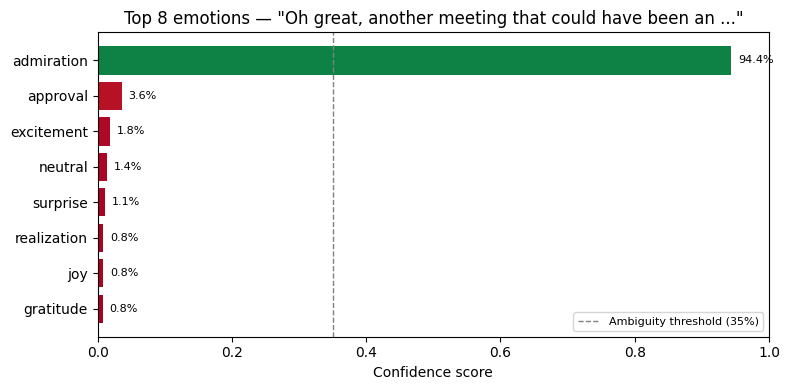

Got: admiration (94.4%)

[Negation]
Expected: annoyance/disappointment
Why it may fail: approval or neutral — DistilRoBERTa-family models often miss negation scope

Text: "I am not happy about this at all."
Prediction: DISAPPROVAL (47.9%)



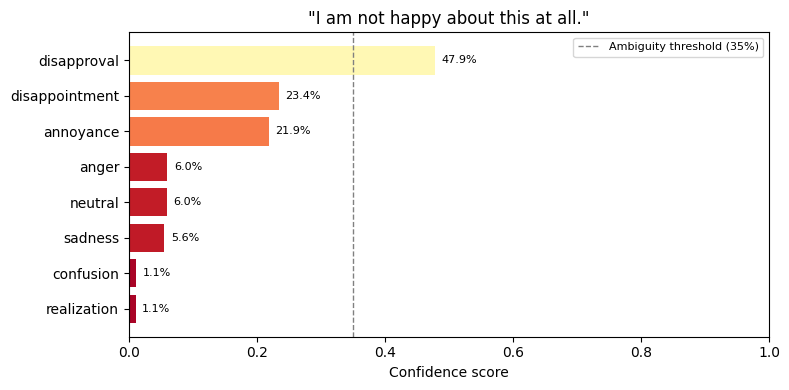

Got: disapproval (47.9%)

[Mixed emotion]
Expected: grief + joy simultaneously
Why it may fail: joy only — single-label models cannot represent coexistence

Text: "It was the best day of my life, but she wasn't there to see it."
Prediction: JOY (52.8%)



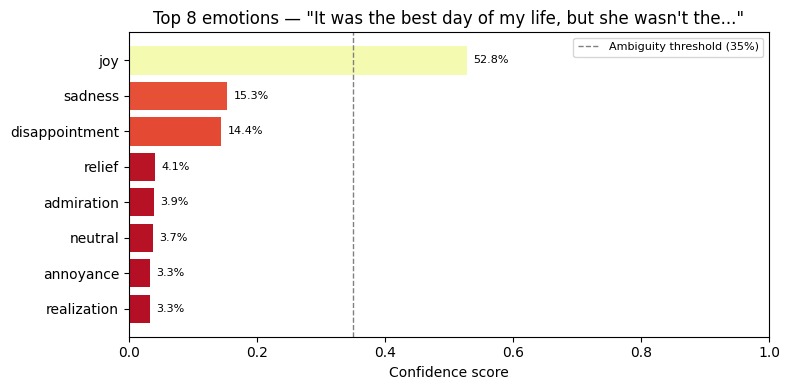

Got: joy (52.8%)

[Culturally indirect grief]
Expected: grief/sadness
Why it may fail: neutral — understated expression underrepresented in training data

Text: "He's been gone for three years now. The house is very quiet."
Prediction: AMBIGUOUS (top score 33.0% < threshold 35%)



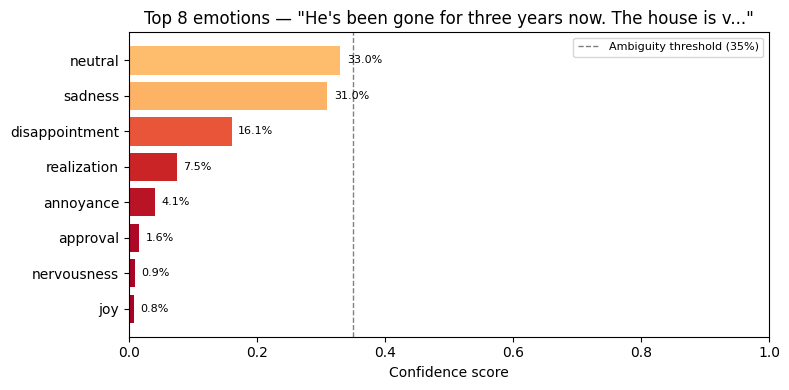

Got: neutral (33.0%)

[Reversed intensifier]
Expected: disgust/anger
Why it may fail: fear or surprise — 'absolutely' is a positive intensifier that confuses the model

Text: "That was absolutely terrible."
Prediction: FEAR (88.8%)



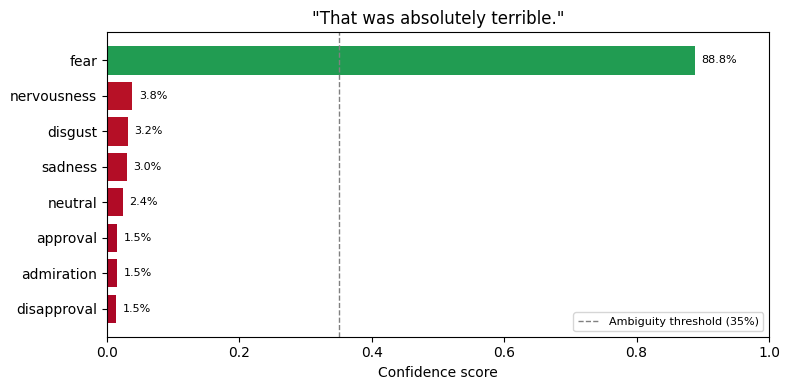

Got: fear (88.8%)

[Professional anger]
Expected: anger/annoyance
Why it may fail: neutral or approval — polite framing suppresses anger signal

Text: "I would appreciate it if this never happened again."
Prediction: ADMIRATION (82.0%)



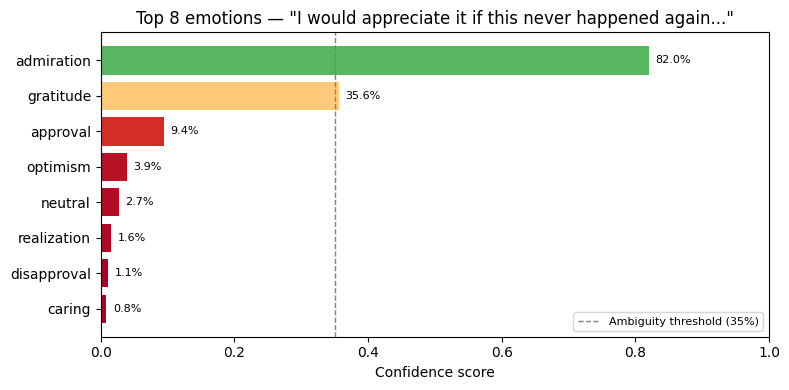

Got: admiration (82.0%)


In [15]:
tricky_inputs = [
    ("Sarcasm",
     "Oh great, another meeting that could have been an email.",
     "annoyance/anger", "joy or amusement — model reads positive surface words"),

    ("Negation",
     "I am not happy about this at all.",
     "annoyance/disappointment", "approval or neutral — DistilRoBERTa-family models often miss negation scope"),

    ("Mixed emotion",
     "It was the best day of my life, but she wasn't there to see it.",
     "grief + joy simultaneously", "joy only — single-label models cannot represent coexistence"),

    ("Culturally indirect grief",
     "He's been gone for three years now. The house is very quiet.",
     "grief/sadness", "neutral — understated expression underrepresented in training data"),

    ("Reversed intensifier",
     "That was absolutely terrible.",
     "disgust/anger", "fear or surprise — 'absolutely' is a positive intensifier that confuses the model"),

    ("Professional anger",
     "I would appreciate it if this never happened again.",
     "anger/annoyance", "neutral or approval — polite framing suppresses anger signal"),
]

print("=" * 65)
for label, text, expected, failure_reason in tricky_inputs:
    print(f"\n[{label}]")
    print(f"Expected: {expected}")
    print(f"Why it may fail: {failure_reason}")
    top_label, top_score = predict_emotions(text)
    print(f"Got: {top_label} ({top_score:.1%})")
    print("=" * 65)

In [16]:
from datasets import load_dataset
from sklearn.metrics import classification_report

# Load test split only — no training happening
ds = load_dataset("dair-ai/emotion", split="test")

# Dataset uses: sadness=0, joy=1, love=2, anger=3, fear=4, surprise=5
DATASET_LABELS = {0: "sadness", 1: "joy", 2: "love", 3: "anger", 4: "fear", 5: "surprise"}

# Map go_emotions 28-class → 6-class (judgment calls noted)
EMOTION_MAP_28_TO_6 = {
    "sadness": "sadness", "grief": "sadness", "remorse": "sadness",
    "disappointment": "sadness", "disapproval": "sadness",
    "joy": "joy", "amusement": "joy", "excitement": "joy",
    "optimism": "joy", "relief": "joy", "pride": "joy",
    "love": "love", "caring": "love", "admiration": "love",
    "desire": "love", "gratitude": "love",
    "anger": "anger", "annoyance": "anger", "disgust": "anger",
    "fear": "fear", "nervousness": "fear",
    "surprise": "surprise", "realization": "surprise", "confusion": "surprise",
    "approval": "joy", "curiosity": "surprise", "embarrassment": "sadness",
    "neutral": "sadness"  # fallback — adjust as needed
}

print("Running evaluation on 200 samples (full test set takes ~5 mins)...")
sample_ds = ds.select(range(200))  # use 200 for speed; remove .select() for full eval

y_true, y_pred = [], []
for item in sample_ds:
    true_label = DATASET_LABELS[item['label']]
    results = classifier(item['text'])[0]
    top_28 = max(results, key=lambda x: x['score'])['label']
    pred_label = EMOTION_MAP_28_TO_6.get(top_28, "sadness")
    y_true.append(true_label)
    y_pred.append(pred_label)

print("\nClassification Report (28→6 mapping, 200 samples):")
print(classification_report(y_true, y_pred))
print("\nNote: This mapping involves judgment calls. Accuracy here reflects")
print("the mapping quality as much as model quality.")

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Running evaluation on 200 samples (full test set takes ~5 mins)...

Classification Report (28→6 mapping, 200 samples):
              precision    recall  f1-score   support

       anger       0.53      0.33      0.41        30
        fear       0.75      0.21      0.33        28
         joy       0.71      0.56      0.63        62
        love       0.17      0.27      0.21        15
     sadness       0.50      0.74      0.60        61
    surprise       0.20      0.50      0.29         4

    accuracy                           0.51       200
   macro avg       0.48      0.44      0.41       200
weighted avg       0.57      0.51      0.51       200


Note: This mapping involves judgment calls. Accuracy here reflects
the mapping quality as much as model quality.
